In [7]:
import pandas as pd
import ast
from collections import Counter
from IPython.display import display

# ==========================================
# [설정] 준환님이 알려주신 경로 그대로 적용
# ==========================================
path_silence = '../../../../data/preprocessed/steam_indie_games_silence.csv' 
path_graded = '../../../../data/preprocessed/steam_indie_games_graded.csv'

print("데이터를 불러오고 병합하는 중...\n")

df_silence = pd.read_csv(path_silence)
df_graded = pd.read_csv(path_graded)

df_silence.columns = df_silence.columns.str.strip()
df_graded.columns = df_graded.columns.str.strip()

# 두 데이터셋 병합
cols = ['appid', 'name', 'total_reviews', 'tags']
df_all = pd.concat([df_silence[cols], df_graded[cols]], ignore_index=True)

# ==========================================
# 1단계: 리뷰 마일스톤 기준 데이터 분할
# ==========================================
def get_review_group(reviews):
    if reviews == 0:
        return 'G0_침묵 (0개)'
    elif 1 <= reviews <= 9:
        return 'G1_시동 (1~9개)'
    elif 10 <= reviews <= 49:
        return 'G2_생존 (10~49개)'
    elif 50 <= reviews <= 499:
        return 'G3_도약 (50~499개)'
    else:
        return 'G4_안착 (500개 이상)'

df_all['review_group'] = df_all['total_reviews'].apply(get_review_group)

# 태그 파싱 및 개수 추출
def extract_tags(tag_str):
    try:
        tags_dict = ast.literal_eval(tag_str)
        return list(tags_dict.keys())
    except:
        return []

df_all['tag_list'] = df_all['tags'].apply(extract_tags)
df_all['tag_count'] = df_all['tag_list'].apply(len)

# ==========================================
# 2단계: 태그 개수(Count)와 흥행의 상관성 분석
# ==========================================
print("="*60)
print("▶ [2단계] 그룹별 평균 태그 개수 및 흥행 상관성 분석")
print("="*60)

tag_count_summary = df_all.groupby('review_group')['tag_count'].agg(['mean', 'median', 'count']).rename(columns={'mean':'평균 태그 수', 'median':'중앙값', 'count':'게임 수'})
print("\n[구간별 평균 태그 개수]")
display(tag_count_summary.round(1))

# 태그 개수 구간별 생존율(리뷰 50개 이상 도달 확률)
bins = [0, 5, 10, 15, 20, 100] # 20개 이상인 경우도 포함
labels = ['1~5개', '6~10개', '11~15개', '16~20개', '21개 이상']
df_all['tag_count_bin'] = pd.cut(df_all['tag_count'], bins=bins, labels=labels)

# 리뷰 50개 이상을 '성공(도약)'으로 정의
df_all['is_success'] = df_all['total_reviews'] >= 50
success_rate = df_all.groupby('tag_count_bin', observed=True)['is_success'].mean() * 100

print("\n[태그 개수 구간별 리뷰 50개 이상 도달 확률(%)]")
display(pd.DataFrame({'도달 확률(%)': success_rate}).round(2))

# ==========================================
# 3단계: 그룹별 태그 순위(Rank) 및 진화 과정 분석
# ==========================================
print("\n" + "="*60)
print("▶ [3단계] 마일스톤별 태그 생태계 변화")
print("="*60)

target_groups = ['G0_침묵 (0개)', 'G1_시동 (1~9개)', 'G2_생존 (10~49개)', 'G3_도약 (50~499개)']
group_stats = {}

for group in target_groups:
    group_df = df_all[df_all['review_group'] == group]
    total_games = len(group_df)
    if total_games == 0: continue
        
    all_tags = []
    for tags in group_df['tag_list']:
        all_tags.extend(tags)
        
    tag_counts = Counter(all_tags)
    # 해당 그룹 내에서 특정 태그가 쓰인 게임의 비율(%)
    tag_rates = {tag: (count / total_games) * 100 for tag, count in tag_counts.items()}
    group_stats[group] = pd.Series(tag_rates)

compare_df = pd.DataFrame(group_stats).fillna(0)

# 범용적인 공통 태그 제외 (특징을 더 명확히 보기 위함)
common_tags = ['Indie', 'Singleplayer', '2D', '3D', 'Action', 'Adventure', 'Casual', 'Simulation']
compare_filtered = compare_df.drop(index=[t for t in common_tags if t in compare_df.index], errors='ignore')

# 3-1. 구간별 TOP 10 출력
for group in target_groups:
    if group in compare_filtered.columns:
        print(f"\n[{group} - 가장 많이 쓰인 핵심 태그 TOP 10 (%)]")
        display(compare_filtered[[group]].sort_values(by=group, ascending=False).head(10).round(1))

# 3-2. 성공 방정식 및 함정 태그 추출
if 'G0_침묵 (0개)' in compare_filtered.columns and 'G3_도약 (50~499개)' in compare_filtered.columns:
    compare_filtered['성장폭 (%p)'] = compare_filtered['G3_도약 (50~499개)'] - compare_filtered['G0_침묵 (0개)']
    
    print("\n💡 [성장 동력 태그] G0에는 없으나 G3로 갈수록 폭증하는 태그 (최소 10% 이상 점유)")
    rising_tags = compare_filtered[compare_filtered['G3_도약 (50~499개)'] >= 10]
    display(rising_tags.sort_values(by='성장폭 (%p)', ascending=False)[['G0_침묵 (0개)', 'G3_도약 (50~499개)', '성장폭 (%p)']].head(10).round(1))

    print("\n💀 [데스밸리 함정 태그] G0에 유독 많으나 G3로 갈수록 도태되는 태그")
    trap_tags = compare_filtered[compare_filtered['G0_침묵 (0개)'] >= 5]
    display(trap_tags.sort_values(by='성장폭 (%p)', ascending=True)[['G0_침묵 (0개)', 'G3_도약 (50~499개)', '성장폭 (%p)']].head(10).round(1))

데이터를 불러오고 병합하는 중...

▶ [2단계] 그룹별 평균 태그 개수 및 흥행 상관성 분석

[구간별 평균 태그 개수]


,평균 태그 수,중앙값,게임 수
review_group,,,
G0_침묵 (0개),18.2,20.0,143
G1_시동 (1~9개),16.7,19.0,6548
G2_생존 (10~49개),17.8,20.0,5278
G3_도약 (50~499개),18.5,20.0,3216
G4_안착 (500개 이상),19.5,20.0,1183



[태그 개수 구간별 리뷰 50개 이상 도달 확률(%)]


,도달 확률(%)
tag_count_bin,
1~5개,27.91
6~10개,11.11
11~15개,13.64
16~20개,31.06



▶ [3단계] 마일스톤별 태그 생태계 변화

[G0_침묵 (0개) - 가장 많이 쓰인 핵심 태그 TOP 10 (%)]


...

,G3_도약 (50~499개)
Atmospheric,30.6
Exploration,29.9
Story Rich,29.2
RPG,26.6
First-Person,23.9
Cute,23.5
Puzzle,23.4
Pixel Graphics,23.2
Colorful,21.7
Strategy,21.1



💡 [성장 동력 태그] G0에는 없으나 G3로 갈수록 폭증하는 태그 (최소 10% 이상 점유)


,G0_침묵 (0개),G3_도약 (50~499개),성장폭 (%p)
Story Rich,7.7,29.2,21.5
RPG,9.1,26.6,17.6
Horror,4.9,20.6,15.8
First-Person,9.1,23.9,14.8
Atmospheric,16.1,30.6,14.5
Psychological Horror,4.2,16.6,12.4
Multiple Endings,1.4,13.8,12.4
Dark,2.1,13.8,11.7
Anime,3.5,13.7,10.2
Pixel Graphics,13.3,23.2,9.9



💀 [데스밸리 함정 태그] G0에 유독 많으나 G3로 갈수록 도태되는 태그


,G0_침묵 (0개),G3_도약 (50~499개),성장폭 (%p)
Relaxing,47.6,16.2,-31.3
Cartoony,39.2,9.7,-29.5
Minimalist,35.7,6.4,-29.3
Score Attack,31.5,2.8,-28.7
Point & Click,36.4,7.7,-28.6
Cats,30.8,3.0,-27.8
Cute,51.0,23.5,-27.5
Collectathon,30.1,4.0,-26.1
Wholesome,28.0,3.0,-25.0
Time Attack,24.5,0.4,-24.1


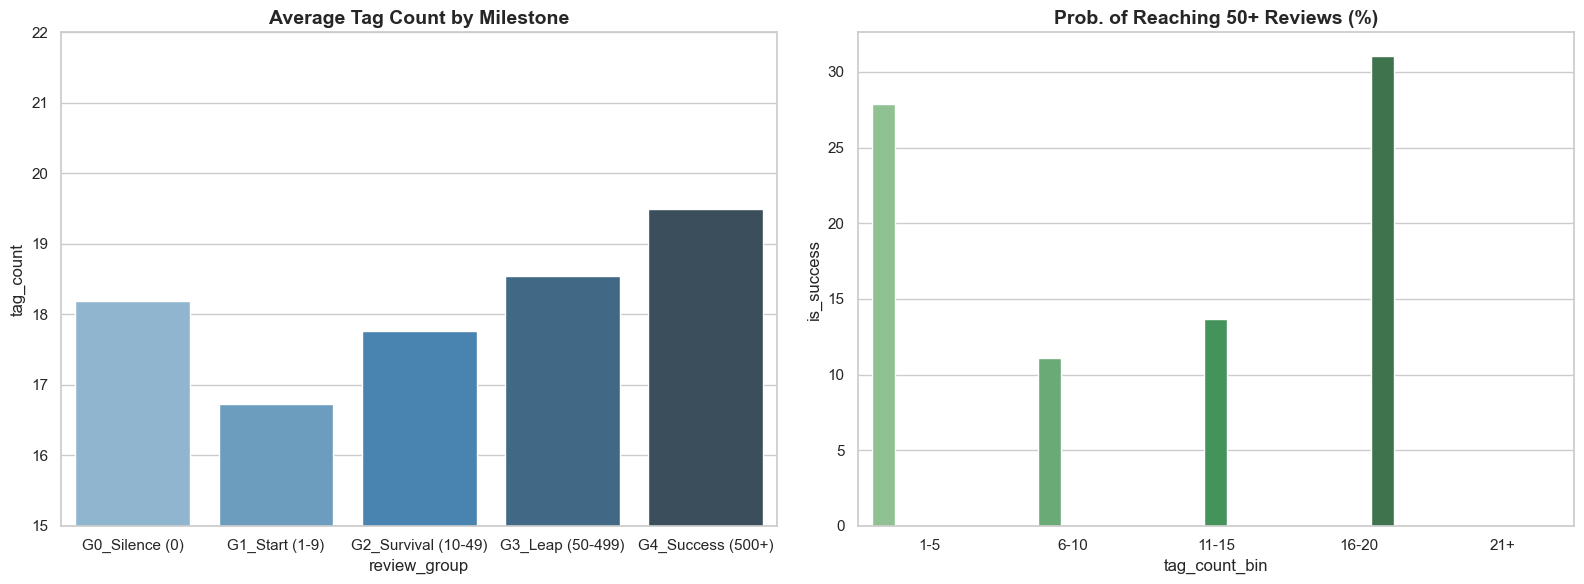

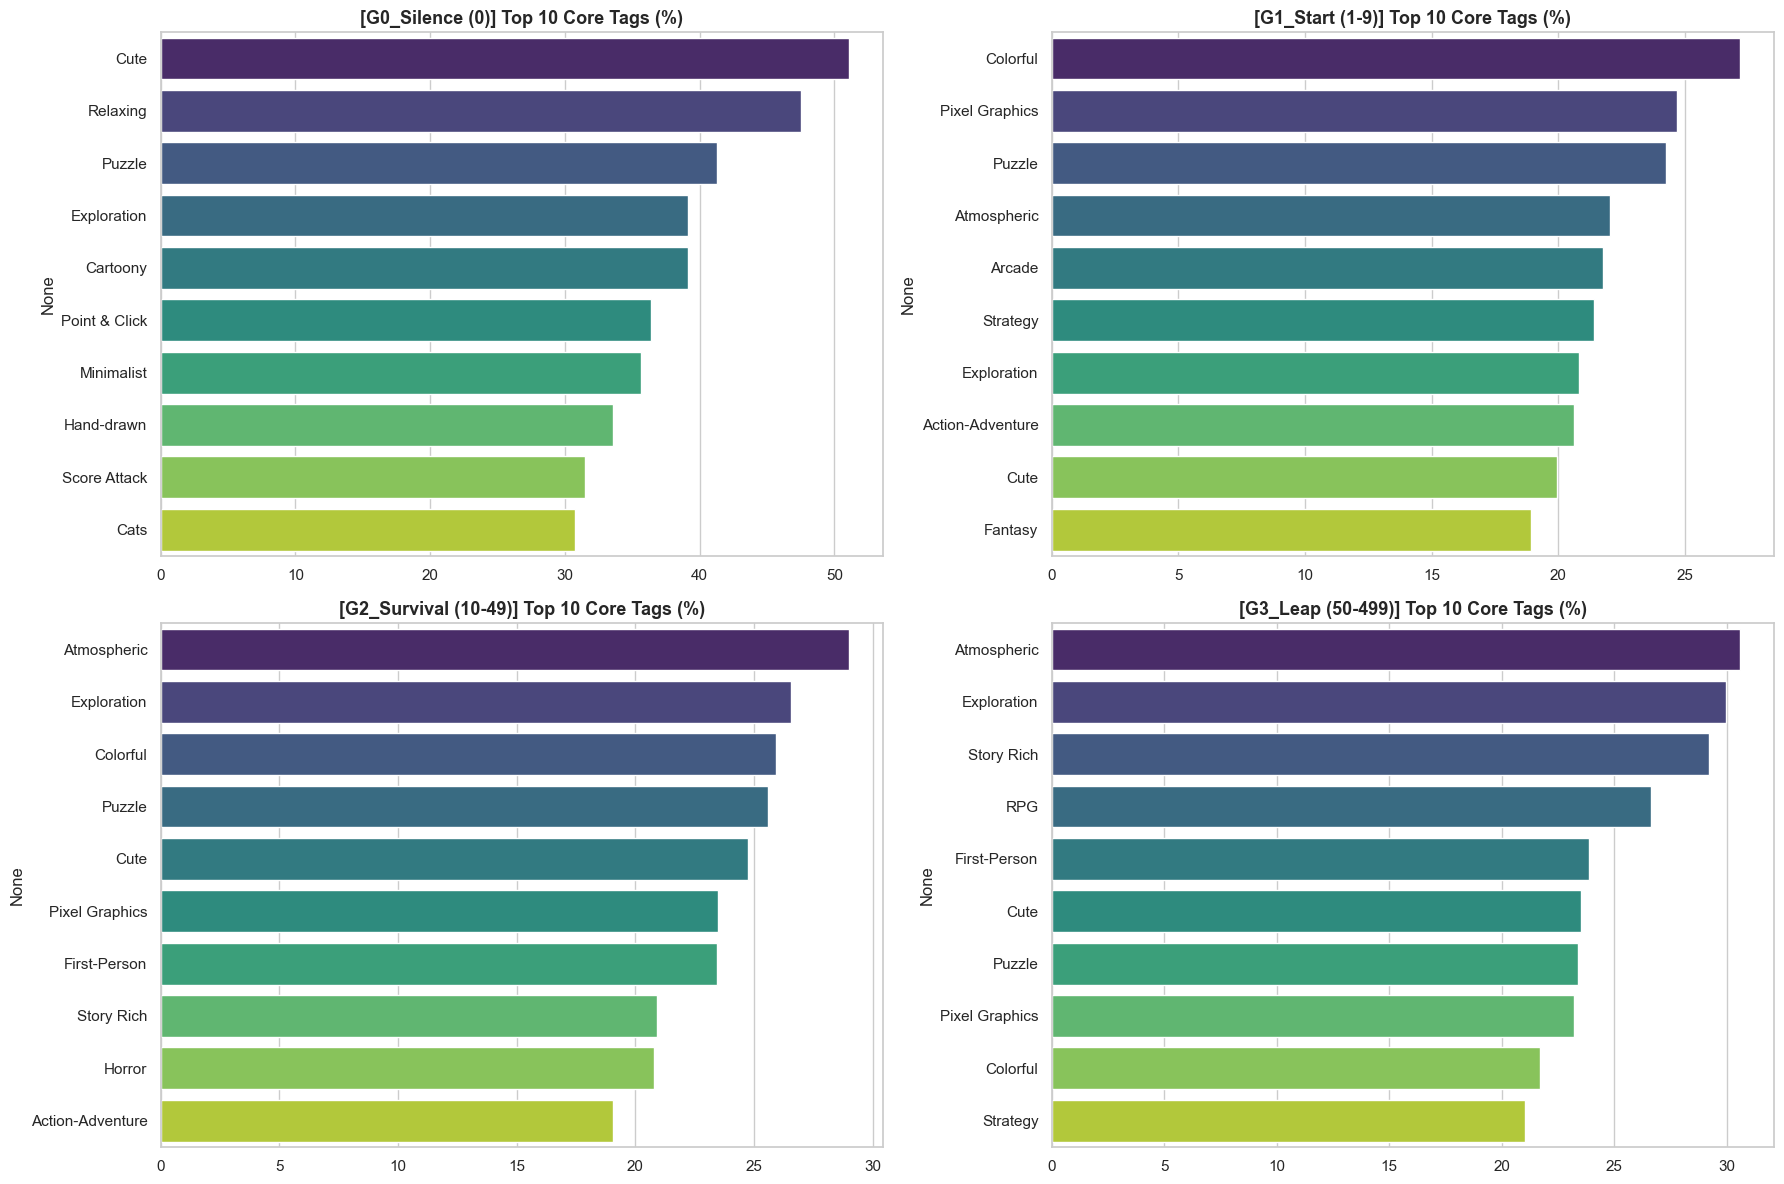

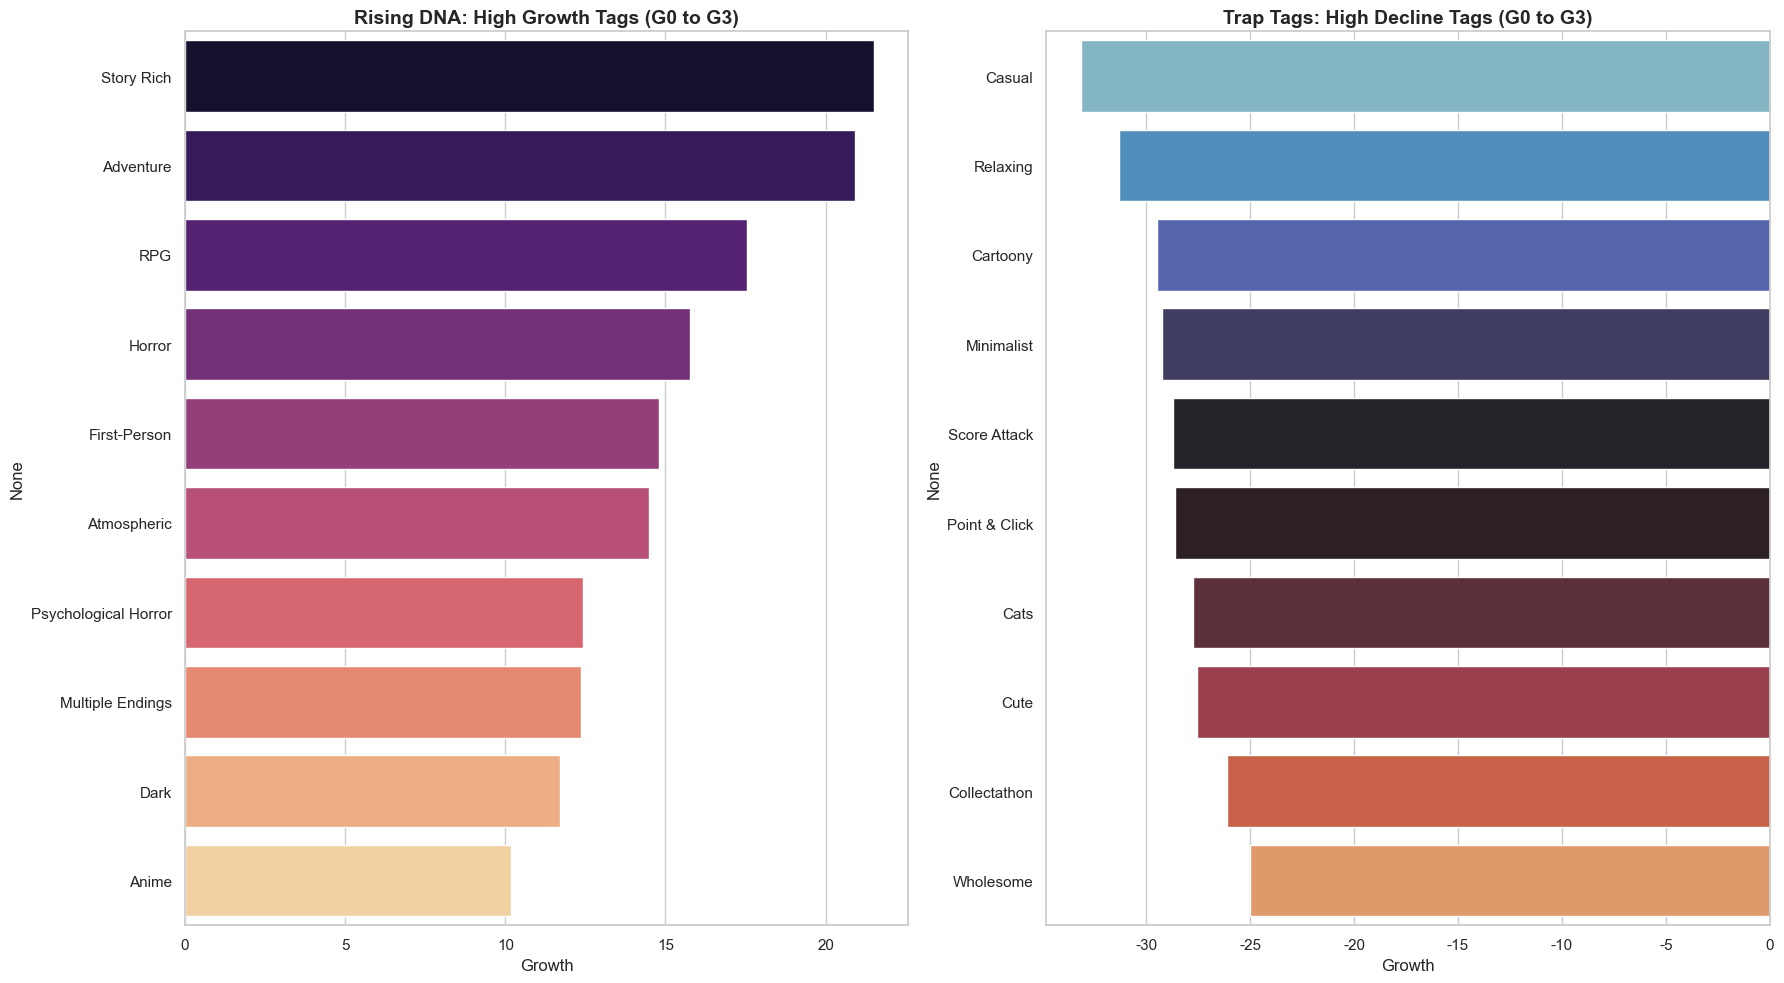

In [16]:
import pandas as pd
import ast
from collections import Counter
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import warnings

# 1. 환경 설정 (경고 무시 및 차트 기본 설정)
warnings.filterwarnings('ignore')
sns.set_theme(style="whitegrid")
plt.rcParams['figure.facecolor'] = 'white'

# ==========================================
# [데이터 로드] - 경로를 준환님 환경에 맞게 유지
# ==========================================
path_silence = '../../../../data/preprocessed/steam_indie_games_silence.csv' 
path_graded = '../../../../data/preprocessed/steam_indie_games_graded.csv'

df_silence = pd.read_csv(path_silence)
df_graded = pd.read_csv(path_graded)
df_silence.columns = df_silence.columns.str.strip()
df_graded.columns = df_graded.columns.str.strip()

cols = ['appid', 'name', 'total_reviews', 'tags']
df_all = pd.concat([df_silence[cols], df_graded[cols]], ignore_index=True)

# ------------------------------------------
# Step 1: Milestone Grouping
# ------------------------------------------
def get_review_group(reviews):
    if reviews == 0: return 'G0_Silence (0)'
    elif 1 <= reviews <= 9: return 'G1_Start (1-9)'
    elif 10 <= reviews <= 49: return 'G2_Survival (10-49)'
    elif 50 <= reviews <= 499: return 'G3_Leap (50-499)'
    else: return 'G4_Success (500+)'

df_all['review_group'] = df_all['total_reviews'].apply(get_review_group)
df_all['tag_list'] = df_all['tags'].apply(lambda x: list(ast.literal_eval(x).keys()) if isinstance(x, str) else [])
df_all['tag_count'] = df_all['tag_list'].apply(len)

# ------------------------------------------
# Step 2: Avg Tags & Success Probability
# ------------------------------------------
fig, ax = plt.subplots(1, 2, figsize=(16, 6))

# Average Tag Count
tag_sum = df_all.groupby('review_group')['tag_count'].mean().reset_index()
sns.barplot(data=tag_sum, x='review_group', y='tag_count', ax=ax[0], hue='review_group', palette='Blues_d', legend=False)
ax[0].set_title('Average Tag Count by Milestone', fontsize=14, fontweight='bold')
ax[0].set_ylim(15, 22)

# Success Probability
bins = [0, 5, 10, 15, 20, 100]
labels = ['1-5', '6-10', '11-15', '16-20', '21+']
df_all['tag_count_bin'] = pd.cut(df_all['tag_count'], bins=bins, labels=labels)
df_all['is_success'] = df_all['total_reviews'] >= 50
succ = df_all.groupby('tag_count_bin', observed=True)['is_success'].mean().reset_index()
succ['is_success'] *= 100

sns.barplot(data=succ, x='tag_count_bin', y='is_success', ax=ax[1], hue='tag_count_bin', palette='Greens_d', legend=False)
ax[1].set_title('Prob. of Reaching 50+ Reviews (%)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# ------------------------------------------
# Step 3: Top Tags Evolution
# ------------------------------------------
target_groups = ['G0_Silence (0)', 'G1_Start (1-9)', 'G2_Survival (10-49)', 'G3_Leap (50-499)']
group_stats = {}
common_tags = ['Indie', 'Singleplayer', '2D', '3D', 'Action', 'Adventure', 'Casual', 'Simulation']

fig, axes = plt.subplots(2, 2, figsize=(18, 12))
axes = axes.flatten()

for i, group in enumerate(target_groups):
    group_df = df_all[df_all['review_group'] == group]
    all_raw = [tag for tags in group_df['tag_list'] for tag in tags]
    
    # Filter for Rank Plot
    filtered = [tag for tag in all_raw if tag not in common_tags]
    counts = pd.Series(Counter(filtered)).sort_values(ascending=False).head(10)
    rates = (counts / len(group_df)) * 100
    
    sns.barplot(x=rates.values, y=rates.index, ax=axes[i], hue=rates.index, palette='viridis', legend=False)
    axes[i].set_title(f'[{group}] Top 10 Core Tags (%)', fontsize=13, fontweight='bold')
    
    # Save all tag rates for next step
    full_c = Counter(all_raw)
    group_stats[group] = pd.Series({tag: (c / len(group_df)) * 100 for tag, c in full_c.items()})

plt.tight_layout()
plt.show()

# ------------------------------------------
# Step 4: Rising DNA vs Trap Tags (Error Fixed)
# ------------------------------------------
compare_df = pd.DataFrame(group_stats).fillna(0)
compare_df['Growth'] = compare_df['G3_Leap (50-499)'] - compare_df['G0_Silence (0)']

fig, ax = plt.subplots(1, 2, figsize=(18, 10))

# Rising DNA (Selecting specific columns to avoid mismatch)
rising = compare_df[compare_df['G3_Leap (50-499)'] >= 10].sort_values(by='Growth', ascending=False).head(10)
sns.barplot(x=rising['Growth'], y=rising.index, ax=ax[0], hue=rising.index, palette='magma', legend=False)
ax[0].set_title('Rising DNA: High Growth Tags (G0 to G3)', fontsize=14, fontweight='bold')

# Trap Tags
traps = compare_df[compare_df['G0_Silence (0)'] >= 5].sort_values(by='Growth', ascending=True).head(10)
sns.barplot(x=traps['Growth'], y=traps.index, ax=ax[1], hue=traps.index, palette='icefire', legend=False)
ax[1].set_title('Trap Tags: High Decline Tags (G0 to G3)', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.show()

In [20]:
import pandas as pd
import ast
from scipy.stats import chi2_contingency
import numpy as np

# ==========================================
# [데이터 로드 및 전처리] (이전과 동일하게 준비되어 있다고 가정)
# ==========================================
path_silence = '../../../../data/preprocessed/steam_indie_games_silence.csv' 
path_graded = '../../../../data/preprocessed/steam_indie_games_graded.csv'

df_silence = pd.read_csv(path_silence)
df_graded = pd.read_csv(path_graded)
df_silence.columns = df_silence.columns.str.strip()
df_graded.columns = df_graded.columns.str.strip()

cols = ['appid', 'name', 'total_reviews', 'tags']
df_all = pd.concat([df_silence[cols], df_graded[cols]], ignore_index=True)

def get_review_group(reviews):
    if reviews == 0: return 'G0'
    elif 1 <= reviews <= 9: return 'G1'
    elif 10 <= reviews <= 49: return 'G2'
    elif 50 <= reviews <= 499: return 'G3'
    else: return 'G4'

df_all['review_group'] = df_all['total_reviews'].apply(get_review_group)
df_all['tag_list'] = df_all['tags'].apply(lambda x: list(ast.literal_eval(x).keys()) if isinstance(x, str) else [])
df_all['tag_count'] = df_all['tag_list'].apply(len)

bins = [0, 5, 10, 15, 20, 100]
labels = ['1-5', '6-10', '11-15', '16-20', '21+']
df_all['tag_count_bin'] = pd.cut(df_all['tag_count'], bins=bins, labels=labels)
df_all['is_success'] = df_all['total_reviews'] >= 50

# ==========================================
# 📊 검증 1: 태그 개수와 성공률의 독립성 검정
# ==========================================
print("=== [검증 1] 태그 개수 구간과 성공(리뷰 50개 이상) 간의 카이제곱 검정 ===")
contingency_table = pd.crosstab(df_all['tag_count_bin'], df_all['is_success'])

chi2, p_val, dof, expected = chi2_contingency(contingency_table)
print(f"- 카이제곱 통계량(Chi2): {chi2:.2f}")
print(f"- P-value: {p_val:.4e}")
if p_val < 0.05:
    print("👉 [결론] 통계적으로 매우 유의미함. 태그 개수 구간에 따라 성공 확률에 확실한 차이가 존재합니다.\n")
else:
    print("👉 [결론] 유의미하지 않음. 태그 개수는 성공과 관계가 없을 수 있습니다.\n")

# ==========================================
# 📊 검증 2: 핵심 태그의 그룹 간(G0 vs G3) 비율 차이 검정
# ==========================================
print("=== [검증 2] 주요 태그의 G0(침묵) vs G3(도약) 비율 차이 유의성 검정 ===")

df_g0 = df_all[df_all['review_group'] == 'G0']
df_g3 = df_all[df_all['review_group'] == 'G3']
n_g0 = len(df_g0)
n_g3 = len(df_g3)

# 앞서 도출된 핵심 태그 리스트
target_tags = {
    'Story Rich': '성장 동력 (+)',
    'RPG': '성장 동력 (+)',
    'Horror': '성장 동력 (+)',
    'Relaxing': '데스밸리 함정 (-)',
    'Cute': '데스밸리 함정 (-)'
}

results = []

for tag, tag_type in target_tags.items():
    # 각 그룹에서 해당 태그를 가진 게임 수
    count_g0 = sum(df_g0['tag_list'].apply(lambda x: tag in x))
    count_g3 = sum(df_g3['tag_list'].apply(lambda x: tag in x))
    
    # 2x2 교차표 생성: [[G0에 태그있음, G0에 태그없음], [G3에 태그있음, G3에 태그없음]]
    table = [
        [count_g0, n_g0 - count_g0],
        [count_g3, n_g3 - count_g3]
    ]
    
    c2, p, _, _ = chi2_contingency(table)
    
    results.append({
        '태그': tag,
        '유형': tag_type,
        'G0 비중(%)': round((count_g0 / n_g0) * 100, 1),
        'G3 비중(%)': round((count_g3 / n_g3) * 100, 1),
        'P-value': p,
        '유의미성': 'Yes' if p < 0.05 else 'No'
    })

results_df = pd.DataFrame(results)
# P-value를 보기 좋게 포맷팅
results_df['P-value'] = results_df['P-value'].apply(lambda x: '< 0.001' if x < 0.001 else f"{x:.4f}")
print(results_df.to_string(index=False))

=== [검증 1] 태그 개수 구간과 성공(리뷰 50개 이상) 간의 카이제곱 검정 ===
- 카이제곱 통계량(Chi2): 488.12
- P-value: 1.7902e-105
👉 [결론] 통계적으로 매우 유의미함. 태그 개수 구간에 따라 성공 확률에 확실한 차이가 존재합니다.

=== [검증 2] 주요 태그의 G0(침묵) vs G3(도약) 비율 차이 유의성 검정 ===
        태그          유형  G0 비중(%)  G3 비중(%) P-value 유의미성
Story Rich   성장 동력 (+)       7.7      29.2 < 0.001  Yes
       RPG   성장 동력 (+)       9.1      26.6 < 0.001  Yes
    Horror   성장 동력 (+)       4.9      20.6 < 0.001  Yes
  Relaxing 데스밸리 함정 (-)      47.6      16.2 < 0.001  Yes
      Cute 데스밸리 함정 (-)      51.0      23.5 < 0.001  Yes


In [22]:
import pandas as pd
import ast
from scipy.stats import chi2_contingency
import numpy as np
from IPython.display import display

# 1. 데이터 로드 및 전처리 (경로는 준환님 환경에 맞춰 유지)
path_silence = '../../../../data/preprocessed/steam_indie_games_silence.csv' 
path_graded = '../../../../data/preprocessed/steam_indie_games_graded.csv'

df_silence = pd.read_csv(path_silence)
df_graded = pd.read_csv(path_graded)
df_silence.columns = df_silence.columns.str.strip()
df_graded.columns = df_graded.columns.str.strip()

cols = ['appid', 'name', 'total_reviews', 'tags']
df_all = pd.concat([df_silence[cols], df_graded[cols]], ignore_index=True)

# 그룹화 및 태그 파싱
def get_review_group(reviews):
    if reviews == 0: return 'G0'
    elif 1 <= reviews <= 9: return 'G1'
    elif 10 <= reviews <= 49: return 'G2'
    elif 50 <= reviews <= 499: return 'G3'
    else: return 'G4'

df_all['review_group'] = df_all['total_reviews'].apply(get_review_group)
df_all['tag_list'] = df_all['tags'].apply(lambda x: list(ast.literal_eval(x).keys()) if isinstance(x, str) else [])
df_all['tag_count'] = df_all['tag_list'].apply(len)

# 태그 개수 구간 및 성공 여부 설정
bins = [0, 5, 10, 15, 20, 100]
labels = ['1-5', '6-10', '11-15', '16-20', '21+']
df_all['tag_count_bin'] = pd.cut(df_all['tag_count'], bins=bins, labels=labels)
df_all['is_success'] = df_all['total_reviews'] >= 50

# ==========================================
# [검증 1] 태그 개수와 성공률의 독립성 검정
# ==========================================
print("\n" + "="*60)
print("▶ [검증 1] 태그 개수 구간과 성공(리뷰 50개 이상) 간의 카이제곱 검정")
print("="*60)

con_table = pd.crosstab(df_all['tag_count_bin'], df_all['is_success'])
chi2, p_val, dof, expected = chi2_contingency(con_table)

val_1_df = pd.DataFrame({
    'Metric': ['Chi-Square Statistic', 'P-value', 'Degrees of Freedom', 'Statistically Significant'],
    'Value': [f"{chi2:.2f}", f"{p_val:.4e}", dof, 'Yes (p < 0.05)' if p_val < 0.05 else 'No']
})
display(val_1_df)

# ==========================================
# [검증 2] 주요 태그의 그룹 간(G0 vs G3) 비율 차이 검정
# ==========================================
print("\n" + "="*60)
print("▶ [검증 2] 주요 태그의 G0(Silence) vs G3(Leap) 비중 차이 유의성 검정")
print("="*60)

df_g0 = df_all[df_all['review_group'] == 'G0']
df_g3 = df_all[df_all['review_group'] == 'G3']
n_g0, n_g3 = len(df_g0), len(df_g3)

# 분석에서 도출된 핵심 태그들
target_tags = {
    'Story Rich': 'Rising DNA (+)',
    'RPG': 'Rising DNA (+)',
    'Horror': 'Rising DNA (+)',
    'Atmospheric': 'Rising DNA (+)',
    'Relaxing': 'Trap Tag (-)',
    'Cute': 'Trap Tag (-)',
    'Cats': 'Trap Tag (-)'
}

tag_val_results = []
for tag, tag_type in target_tags.items():
    c_g0 = sum(df_g0['tag_list'].apply(lambda x: tag in x))
    c_g3 = sum(df_g3['tag_list'].apply(lambda x: tag in x))
    
    # 카이제곱 검정을 위한 교차표
    table = [[c_g0, n_g0 - c_g0], [c_g3, n_g3 - c_g3]]
    _, p, _, _ = chi2_contingency(table)
    
    tag_val_results.append({
        'Tag': tag,
        'Type': tag_type,
        'G0 Share (%)': round((c_g0 / n_g0) * 100, 1),
        'G3 Share (%)': round((c_g3 / n_g3) * 100, 1),
        'P-value': f"{p:.4e}",
        'Significant': 'Yes' if p < 0.05 else 'No'
    })

display(pd.DataFrame(tag_val_results))


▶ [검증 1] 태그 개수 구간과 성공(리뷰 50개 이상) 간의 카이제곱 검정


,Metric,Value
0,Chi-Square Statistic,488.12
1,P-value,1.7902e-105
2,Degrees of Freedom,3
3,Statistically Significant,Yes (p < 0.05)



▶ [검증 2] 주요 태그의 G0(Silence) vs G3(Leap) 비중 차이 유의성 검정


,Tag,Type,G0 Share (%),G3 Share (%),P-value,Significant
0,Story Rich,Rising DNA (+),7.7,29.2,3.9654e-08,Yes
1,RPG,Rising DNA (+),9.1,26.6,4.3944e-06,Yes
2,Horror,Rising DNA (+),4.9,20.6,6.7027e-06,Yes
3,Atmospheric,Rising DNA (+),16.1,30.6,3.1064e-04,Yes
4,Relaxing,Trap Tag (-),47.6,16.2,1.7501e-21,Yes
5,Cute,Trap Tag (-),51.0,23.5,1.6389e-13,Yes
6,Cats,Trap Tag (-),30.8,3.0,1.7512e-57,Yes


In [23]:
import pandas as pd
import ast
from scipy.stats import chi2_contingency
import numpy as np
from IPython.display import display

# 1. 데이터 로드 (경로 유지)
path_silence = '../../../../data/preprocessed/steam_indie_games_silence.csv' 
path_graded = '../../../../data/preprocessed/steam_indie_games_graded.csv'

df_silence = pd.read_csv(path_silence)
df_graded = pd.read_csv(path_graded)
df_all = pd.concat([df_silence, df_graded], ignore_index=True)

# 그룹화 및 태그 추출
def get_review_group(reviews):
    if reviews == 0: return 'G0'
    elif 50 <= reviews <= 499: return 'G3'
    return 'Other'

df_all['review_group'] = df_all['total_reviews'].apply(get_review_group)
df_all['tag_list'] = df_all['tags'].apply(lambda x: list(ast.literal_eval(x).keys()) if isinstance(x, str) else [])

# 효과 크기(Cramér's V) 계산 함수
def calculate_cramers_v(chi2, n, rows, cols):
    return np.sqrt(chi2 / (n * min(rows - 1, cols - 1)))

# 효과 크기 해석 함수 (Cohen's 기준)
def interpret_v(v):
    if v < 0.1: return 'Negligible'
    elif v < 0.3: return 'Small'
    elif v < 0.5: return 'Medium'
    else: return 'Large'

# 📊 [검증 2] 주요 태그의 G0 vs G3 비중 차이 및 효과 크기 분석
print("\n" + "="*80)
print("▶ 주요 태그별 G0(Silence) vs G3(Leap) 비중 차이 및 효과 크기(Cramér's V) 분석")
print("="*80)

df_target = df_all[df_all['review_group'].isin(['G0', 'G3'])]
n_total = len(df_target)
df_g0 = df_target[df_target['review_group'] == 'G0']
df_g3 = df_target[df_target['review_group'] == 'G3']

target_tags = {
    'Story Rich': 'Rising DNA (+)', 'RPG': 'Rising DNA (+)', 
    'Horror': 'Rising DNA (+)', 'Atmospheric': 'Rising DNA (+)',
    'Relaxing': 'Trap Tag (-)', 'Cute': 'Trap Tag (-)', 'Cats': 'Trap Tag (-)'
}

results = []
for tag, t_type in target_tags.items():
    c_g0 = sum(df_g0['tag_list'].apply(lambda x: tag in x))
    c_g3 = sum(df_g3['tag_list'].apply(lambda x: tag in x))
    
    # 2x2 교차표
    table = [[c_g0, len(df_g0) - c_g0], [c_g3, len(df_g3) - c_g3]]
    chi2, p, _, _ = chi2_contingency(table)
    
    # 효과 크기 계산
    v = calculate_cramers_v(chi2, len(df_target), 2, 2)
    
    results.append({
        'Tag': tag,
        'Type': t_type,
        'G0 Share (%)': round((c_g0 / len(df_g0)) * 100, 1),
        'G3 Share (%)': round((c_g3 / len(df_g3)) * 100, 1),
        'P-value': f"{p:.4e}",
        'Cramér\'s V': round(v, 3),
        'Effect Size': interpret_v(v)
    })

display(pd.DataFrame(results))


▶ 주요 태그별 G0(Silence) vs G3(Leap) 비중 차이 및 효과 크기(Cramér's V) 분석


,Tag,Type,G0 Share (%),G3 Share (%),P-value,Cramér's V,Effect Size
0,Story Rich,Rising DNA (+),7.7,29.2,3.9654e-08,0.095,Negligible
1,RPG,Rising DNA (+),9.1,26.6,4.3944e-06,0.079,Negligible
2,Horror,Rising DNA (+),4.9,20.6,6.7027e-06,0.078,Negligible
3,Atmospheric,Rising DNA (+),16.1,30.6,3.1064e-04,0.062,Negligible
4,Relaxing,Trap Tag (-),47.6,16.2,1.7501e-21,0.164,Small
5,Cute,Trap Tag (-),51.0,23.5,1.6389e-13,0.127,Small
6,Cats,Trap Tag (-),30.8,3.0,1.7512e-57,0.276,Small


In [24]:
import pandas as pd
import ast
from collections import Counter
from IPython.display import display
from scipy.stats import chi2_contingency
import numpy as np

# ==========================================
# [설정] 준환님이 알려주신 경로 그대로 적용
# ==========================================
path_silence = '../../../../data/preprocessed/steam_indie_games_silence.csv' 
path_graded = '../../../../data/preprocessed/steam_indie_games_graded.csv'

print("데이터를 불러오고 병합하는 중...\n")

df_silence = pd.read_csv(path_silence)
df_graded = pd.read_csv(path_graded)

df_silence.columns = df_silence.columns.str.strip()
df_graded.columns = df_graded.columns.str.strip()

# 두 데이터셋 병합
cols = ['appid', 'name', 'total_reviews', 'tags']
df_all = pd.concat([df_silence[cols], df_graded[cols]], ignore_index=True)

# ==========================================
# 1단계: 리뷰 마일스톤 기준 데이터 분할
# ==========================================
def get_review_group(reviews):
    if reviews == 0:
        return 'G0_침묵 (0개)'
    elif 1 <= reviews <= 9:
        return 'G1_시동 (1~9개)'
    elif 10 <= reviews <= 49:
        return 'G2_생존 (10~49개)'
    elif 50 <= reviews <= 499:
        return 'G3_도약 (50~499개)'
    else:
        return 'G4_안착 (500개 이상)'

df_all['review_group'] = df_all['total_reviews'].apply(get_review_group)

# 태그 파싱 및 개수 추출
def extract_tags(tag_str):
    try:
        tags_dict = ast.literal_eval(tag_str)
        return list(tags_dict.keys())
    except:
        return []

df_all['tag_list'] = df_all['tags'].apply(extract_tags)
df_all['tag_count'] = df_all['tag_list'].apply(len)

# ==========================================
# 2단계: 태그 개수(Count)와 흥행의 상관성 분석
# ==========================================
print("="*60)
print("▶ [2단계] 그룹별 평균 태그 개수 및 흥행 상관성 분석")
print("="*60)

tag_count_summary = df_all.groupby('review_group')['tag_count'].agg(['mean', 'median', 'count']).rename(columns={'mean':'평균 태그 수', 'median':'중앙값', 'count':'게임 수'})
print("\n[구간별 평균 태그 개수]")
display(tag_count_summary.round(1))

# 태그 개수 구간별 생존율(리뷰 50개 이상 도달 확률)
bins = [0, 5, 10, 15, 20, 100] # 20개 이상인 경우도 포함
labels = ['1~5개', '6~10개', '11~15개', '16~20개', '21개 이상']
df_all['tag_count_bin'] = pd.cut(df_all['tag_count'], bins=bins, labels=labels)

# 리뷰 50개 이상을 '성공(도약)'으로 정의
df_all['is_success'] = df_all['total_reviews'] >= 50
success_rate = df_all.groupby('tag_count_bin', observed=True)['is_success'].mean() * 100

print("\n[태그 개수 구간별 리뷰 50개 이상 도달 확률(%)]")
display(pd.DataFrame({'도달 확률(%)': success_rate}).round(2))

# ==========================================
# 3단계: 그룹별 태그 순위(Rank) 및 진화 과정 분석
# ==========================================
print("\n" + "="*60)
print("▶ [3단계] 마일스톤별 태그 생태계 변화 (통계 검정 포함)")
print("="*60)

target_groups = ['G0_침묵 (0개)', 'G1_시동 (1~9개)', 'G2_생존 (10~49개)', 'G3_도약 (50~499개)']
group_stats = {}

for group in target_groups:
    group_df = df_all[df_all['review_group'] == group]
    total_games = len(group_df)
    if total_games == 0: continue
        
    all_tags = []
    for tags in group_df['tag_list']:
        all_tags.extend(tags)
        
    tag_counts = Counter(all_tags)
    # 해당 그룹 내에서 특정 태그가 쓰인 게임의 비율(%)
    tag_rates = {tag: (count / total_games) * 100 for tag, count in tag_counts.items()}
    group_stats[group] = pd.Series(tag_rates)

compare_df = pd.DataFrame(group_stats).fillna(0)

# 범용적인 공통 태그 제외
common_tags = ['Indie', 'Singleplayer', '2D', '3D', 'Action', 'Adventure', 'Casual', 'Simulation']
compare_filtered = compare_df.drop(index=[t for t in common_tags if t in compare_df.index], errors='ignore')

# 3-1. 구간별 TOP 10 출력
for group in target_groups:
    if group in compare_filtered.columns:
        print(f"\n[{group} - 가장 많이 쓰인 핵심 태그 TOP 10 (%)]")
        display(compare_filtered[[group]].sort_values(by=group, ascending=False).head(10).round(1))

# ---------------------------------------------------------
# 통계 검정 및 효과 크기 계산용 헬퍼 함수
# ---------------------------------------------------------
df_g0 = df_all[df_all['review_group'] == 'G0_침묵 (0개)']
df_g3 = df_all[df_all['review_group'] == 'G3_도약 (50~499개)']

def get_tag_stats(tag):
    c_g0 = sum(df_g0['tag_list'].apply(lambda x: tag in x))
    c_g3 = sum(df_g3['tag_list'].apply(lambda x: tag in x))
    n_g0 = len(df_g0)
    n_g3 = len(df_g3)
    
    # 2x2 교차표
    table = [[c_g0, n_g0 - c_g0], [c_g3, n_g3 - c_g3]]
    chi2, p, _, _ = chi2_contingency(table)
    
    # 효과 크기 (Cramér's V)
    v = np.sqrt(chi2 / (n_g0 + n_g3))
    
    # P-value 직관적 표시
    p_str = "< 0.001" if p < 0.001 else f"{p:.4f}"
    
    return pd.Series([p_str, round(v, 3)], index=['P-value', "Cramér's V"])

# 3-2. 성공 방정식 및 함정 태그 추출 (+ 통계 수치 병합)
if 'G0_침묵 (0개)' in compare_filtered.columns and 'G3_도약 (50~499개)' in compare_filtered.columns:
    compare_filtered['성장폭 (%p)'] = compare_filtered['G3_도약 (50~499개)'] - compare_filtered['G0_침묵 (0개)']
    
    print("\n💡 [성장 동력 태그] G0에는 없으나 G3로 갈수록 폭증하는 태그 (최소 10% 이상 점유)")
    rising_top10 = compare_filtered[compare_filtered['G3_도약 (50~499개)'] >= 10].sort_values(by='성장폭 (%p)', ascending=False)[['G0_침묵 (0개)', 'G3_도약 (50~499개)', '성장폭 (%p)']].head(10)
    # 통계 계산 적용
    stats_rising = rising_top10.index.to_series().apply(get_tag_stats)
    display(pd.concat([rising_top10.round(1), stats_rising], axis=1))

    print("\n💀 [데스밸리 함정 태그] G0에 유독 많으나 G3로 갈수록 도태되는 태그")
    trap_top10 = compare_filtered[compare_filtered['G0_침묵 (0개)'] >= 5].sort_values(by='성장폭 (%p)', ascending=True)[['G0_침묵 (0개)', 'G3_도약 (50~499개)', '성장폭 (%p)']].head(10)
    # 통계 계산 적용
    stats_trap = trap_top10.index.to_series().apply(get_tag_stats)
    display(pd.concat([trap_top10.round(1), stats_trap], axis=1))

데이터를 불러오고 병합하는 중...

▶ [2단계] 그룹별 평균 태그 개수 및 흥행 상관성 분석

[구간별 평균 태그 개수]


,평균 태그 수,중앙값,게임 수
review_group,,,
G0_침묵 (0개),18.2,20.0,143
G1_시동 (1~9개),16.7,19.0,6548
G2_생존 (10~49개),17.8,20.0,5278
G3_도약 (50~499개),18.5,20.0,3216
G4_안착 (500개 이상),19.5,20.0,1183



[태그 개수 구간별 리뷰 50개 이상 도달 확률(%)]


,도달 확률(%)
tag_count_bin,
1~5개,27.91
6~10개,11.11
11~15개,13.64
16~20개,31.06



▶ [3단계] 마일스톤별 태그 생태계 변화 (통계 검정 포함)

[G0_침묵 (0개) - 가장 많이 쓰인 핵심 태그 TOP 10 (%)]


...

,G3_도약 (50~499개)
Atmospheric,30.6
Exploration,29.9
Story Rich,29.2
RPG,26.6
First-Person,23.9
Cute,23.5
Puzzle,23.4
Pixel Graphics,23.2
Colorful,21.7
Strategy,21.1



💡 [성장 동력 태그] G0에는 없으나 G3로 갈수록 폭증하는 태그 (최소 10% 이상 점유)


,G0_침묵 (0개),G3_도약 (50~499개),성장폭 (%p),P-value,Cramér's V
Story Rich,7.7,29.2,21.5,< 0.001,0.095
RPG,9.1,26.6,17.6,< 0.001,0.079
Horror,4.9,20.6,15.8,< 0.001,0.078
First-Person,9.1,23.9,14.8,< 0.001,0.069
Atmospheric,16.1,30.6,14.5,< 0.001,0.062
Psychological Horror,4.2,16.6,12.4,< 0.001,0.066
Multiple Endings,1.4,13.8,12.4,< 0.001,0.072
Dark,2.1,13.8,11.7,< 0.001,0.067
Anime,3.5,13.7,10.2,< 0.001,0.058
Pixel Graphics,13.3,23.2,9.9,0.0076,0.046



💀 [데스밸리 함정 태그] G0에 유독 많으나 G3로 갈수록 도태되는 태그


,G0_침묵 (0개),G3_도약 (50~499개),성장폭 (%p),P-value,Cramér's V
Relaxing,47.6,16.2,-31.3,< 0.001,0.164
Cartoony,39.2,9.7,-29.5,< 0.001,0.188
Minimalist,35.7,6.4,-29.3,< 0.001,0.219
Score Attack,31.5,2.8,-28.7,< 0.001,0.292
Point & Click,36.4,7.7,-28.6,< 0.001,0.200
Cats,30.8,3.0,-27.8,< 0.001,0.276
Cute,51.0,23.5,-27.5,< 0.001,0.127
Collectathon,30.1,4.0,-26.1,< 0.001,0.236
Wholesome,28.0,3.0,-25.0,< 0.001,0.253
Time Attack,24.5,0.4,-24.1,< 0.001,0.408


In [25]:
import pandas as pd
import ast
from scipy.stats import chi2_contingency
import numpy as np
from IPython.display import display

# 데이터 로드 로직 (이전과 동일)
# ...

results = []
for tag, t_type in target_tags.items():
    c_g0 = sum(df_g0['tag_list'].apply(lambda x: tag in x))
    c_g3 = sum(df_g3['tag_list'].apply(lambda x: tag in x))
    
    # 2x2 테이블: [[태그있음_G3, 태그없음_G3], [태그있음_G0, 태그없음_G0]]
    n_g0_no = len(df_g0) - c_g0
    n_g3_no = len(df_g3) - c_g3
    
    # Odds Ratio 계산 (0 나누기 방지를 위해 아주 작은 값 더함)
    odds_g3 = c_g3 / (n_g3_no + 1e-9)
    odds_g0 = c_g0 / (n_g0_no + 1e-9)
    odds_ratio = odds_g3 / (odds_g0 + 1e-9)
    
    # 카이제곱 및 Cramér's V
    table = [[c_g0, n_g0 - c_g0], [c_g3, n_g3 - c_g3]]
    chi2, p, _, _ = chi2_contingency(table)
    v = np.sqrt(chi2 / ( (len(df_g0)+len(df_g3)) * 1))
    
    results.append({
        'Tag': tag,
        'Type': t_type,
        'P-value': f"{p:.4e}",
        'Cramér\'s V': round(v, 3),
        'Odds Ratio': round(odds_ratio, 2),
        'Interpretation': f"Success prob is {round(odds_ratio, 1)}x higher" if odds_ratio > 1 else f"Success prob is {round(1/odds_ratio, 1)}x lower"
    })

display(pd.DataFrame(results))

,Tag,Type,P-value,Cramér's V,Odds Ratio,Interpretation
0,Story Rich,Rising DNA (+),3.9654e-08,0.095,4.95,Success prob is 4.9x higher
1,RPG,Rising DNA (+),4.3944e-06,0.079,3.63,Success prob is 3.6x higher
2,Horror,Rising DNA (+),6.7027e-06,0.078,5.06,Success prob is 5.1x higher
3,Atmospheric,Rising DNA (+),3.1064e-04,0.062,2.30,Success prob is 2.3x higher
4,Relaxing,Trap Tag (-),1.7501e-21,0.164,0.21,Success prob is 4.7x lower
5,Cute,Trap Tag (-),1.6389e-13,0.127,0.29,Success prob is 3.4x lower
6,Cats,Trap Tag (-),1.7512e-57,0.276,0.07,Success prob is 14.3x lower


In [26]:
import pandas as pd
import ast
from collections import Counter
from IPython.display import display
from scipy.stats import chi2_contingency
import numpy as np

# ==========================================
# [설정] 경로 적용
# ==========================================
path_silence = '../../../../data/preprocessed/steam_indie_games_silence.csv' 
path_graded = '../../../../data/preprocessed/steam_indie_games_graded.csv'

print("데이터를 불러오고 병합하는 중...\n")

df_silence = pd.read_csv(path_silence)
df_graded = pd.read_csv(path_graded)

df_silence.columns = df_silence.columns.str.strip()
df_graded.columns = df_graded.columns.str.strip()

# 두 데이터셋 병합
cols = ['appid', 'name', 'total_reviews', 'tags']
df_all = pd.concat([df_silence[cols], df_graded[cols]], ignore_index=True)

# ==========================================
# 1단계: 리뷰 마일스톤 기준 데이터 분할
# ==========================================
def get_review_group(reviews):
    if reviews == 0:
        return 'G0_침묵 (0개)'
    elif 1 <= reviews <= 9:
        return 'G1_시동 (1~9개)'
    elif 10 <= reviews <= 49:
        return 'G2_생존 (10~49개)'
    elif 50 <= reviews <= 499:
        return 'G3_도약 (50~499개)'
    else:
        return 'G4_안착 (500개 이상)'

df_all['review_group'] = df_all['total_reviews'].apply(get_review_group)

def extract_tags(tag_str):
    try:
        tags_dict = ast.literal_eval(tag_str)
        return list(tags_dict.keys())
    except:
        return []

df_all['tag_list'] = df_all['tags'].apply(extract_tags)
df_all['tag_count'] = df_all['tag_list'].apply(len)

# ==========================================
# 2단계: 태그 개수(Count)와 흥행의 상관성 분석
# ==========================================
print("="*60)
print("▶ [2단계] 그룹별 평균 태그 개수 및 흥행 상관성 분석")
print("="*60)

tag_count_summary = df_all.groupby('review_group')['tag_count'].agg(['mean', 'median', 'count']).rename(columns={'mean':'평균 태그 수', 'median':'중앙값', 'count':'게임 수'})
print("\n[구간별 평균 태그 개수]")
display(tag_count_summary.round(1))

bins = [0, 5, 10, 15, 20, 100]
labels = ['1~5개', '6~10개', '11~15개', '16~20개', '21개 이상']
df_all['tag_count_bin'] = pd.cut(df_all['tag_count'], bins=bins, labels=labels)

df_all['is_success'] = df_all['total_reviews'] >= 50
success_rate = df_all.groupby('tag_count_bin', observed=True)['is_success'].mean() * 100

print("\n[태그 개수 구간별 리뷰 50개 이상 도달 확률(%)]")
display(pd.DataFrame({'도달 확률(%)': success_rate}).round(2))

# ==========================================
# 3단계: 그룹별 태그 순위(Rank) 및 진화 과정 분석
# ==========================================
print("\n" + "="*60)
print("▶ [3단계] 마일스톤별 태그 생태계 변화 (통계 검정 및 승산비 포함)")
print("="*60)

target_groups = ['G0_침묵 (0개)', 'G1_시동 (1~9개)', 'G2_생존 (10~49개)', 'G3_도약 (50~499개)']
group_stats = {}

for group in target_groups:
    group_df = df_all[df_all['review_group'] == group]
    total_games = len(group_df)
    if total_games == 0: continue
        
    all_tags = []
    for tags in group_df['tag_list']:
        all_tags.extend(tags)
        
    tag_counts = Counter(all_tags)
    tag_rates = {tag: (count / total_games) * 100 for tag, count in tag_counts.items()}
    group_stats[group] = pd.Series(tag_rates)

compare_df = pd.DataFrame(group_stats).fillna(0)

# 범용적인 공통 태그 제외
common_tags = ['Indie', 'Singleplayer', '2D', '3D', 'Action', 'Adventure', 'Casual', 'Simulation']
compare_filtered = compare_df.drop(index=[t for t in common_tags if t in compare_df.index], errors='ignore')

# ---------------------------------------------------------
# 통계 검정, 효과 크기, 승산비(Odds Ratio) 계산 함수
# ---------------------------------------------------------
df_g0 = df_all[df_all['review_group'] == 'G0_침묵 (0개)']
df_g3 = df_all[df_all['review_group'] == 'G3_도약 (50~499개)']

def get_tag_stats(tag):
    c_g0 = sum(df_g0['tag_list'].apply(lambda x: tag in x))
    c_g3 = sum(df_g3['tag_list'].apply(lambda x: tag in x))
    n_g0 = len(df_g0)
    n_g3 = len(df_g3)
    
    # 1. P-value 및 Cramér's V 계산
    table = [[c_g0, n_g0 - c_g0], [c_g3, n_g3 - c_g3]]
    chi2, p, _, _ = chi2_contingency(table)
    v = np.sqrt(chi2 / (n_g0 + n_g3))
    p_str = "< 0.001" if p < 0.001 else f"{p:.4f}"
    
    # 2. 승산비(Odds Ratio) 계산
    # 태그가 있을 때 성공(G3)/실패(G0) 배수 vs 태그가 없을 때 성공/실패 배수
    odds_tag = c_g3 / (c_g0 + 1e-9) 
    odds_no_tag = (n_g3 - c_g3) / ((n_g0 - c_g0) + 1e-9)
    odds_ratio = odds_tag / (odds_no_tag + 1e-9)
    
    # 3. 직관적인 해석 텍스트 생성
    if odds_ratio > 1:
        interpretation = f"성공확률 {odds_ratio:.1f}배 ⬆"
    else:
        interpretation = f"성공확률 {(1/odds_ratio):.1f}배 ⬇"
    
    return pd.Series([p_str, round(v, 3), round(odds_ratio, 2), interpretation], 
                     index=['P-value', "Cramér's V", 'Odds Ratio', '직관적 의미'])

# 3-2. 성공 방정식 및 함정 태그 추출 (+ 통계 수치 병합)
if 'G0_침묵 (0개)' in compare_filtered.columns and 'G3_도약 (50~499개)' in compare_filtered.columns:
    compare_filtered['성장폭 (%p)'] = compare_filtered['G3_도약 (50~499개)'] - compare_filtered['G0_침묵 (0개)']
    
    print("\n💡 [성장 동력 태그] G0에는 없으나 G3로 갈수록 폭증하는 태그 (최소 10% 이상 점유)")
    rising_top10 = compare_filtered[compare_filtered['G3_도약 (50~499개)'] >= 10].sort_values(by='성장폭 (%p)', ascending=False)[['G0_침묵 (0개)', 'G3_도약 (50~499개)', '성장폭 (%p)']].head(10)
    stats_rising = rising_top10.index.to_series().apply(get_tag_stats)
    display(pd.concat([rising_top10.round(1), stats_rising], axis=1))

    print("\n💀 [데스밸리 함정 태그] G0에 유독 많으나 G3로 갈수록 도태되는 태그")
    trap_top10 = compare_filtered[compare_filtered['G0_침묵 (0개)'] >= 5].sort_values(by='성장폭 (%p)', ascending=True)[['G0_침묵 (0개)', 'G3_도약 (50~499개)', '성장폭 (%p)']].head(10)
    stats_trap = trap_top10.index.to_series().apply(get_tag_stats)
    display(pd.concat([trap_top10.round(1), stats_trap], axis=1))

데이터를 불러오고 병합하는 중...

▶ [2단계] 그룹별 평균 태그 개수 및 흥행 상관성 분석

[구간별 평균 태그 개수]


,평균 태그 수,중앙값,게임 수
review_group,,,
G0_침묵 (0개),18.2,20.0,143
G1_시동 (1~9개),16.7,19.0,6548
G2_생존 (10~49개),17.8,20.0,5278
G3_도약 (50~499개),18.5,20.0,3216
G4_안착 (500개 이상),19.5,20.0,1183



[태그 개수 구간별 리뷰 50개 이상 도달 확률(%)]


,도달 확률(%)
tag_count_bin,
1~5개,27.91
6~10개,11.11
11~15개,13.64
16~20개,31.06



▶ [3단계] 마일스톤별 태그 생태계 변화 (통계 검정 및 승산비 포함)

💡 [성장 동력 태그] G0에는 없으나 G3로 갈수록 폭증하는 태그 (최소 10% 이상 점유)


,G0_침묵 (0개),G3_도약 (50~499개),성장폭 (%p),P-value,Cramér's V,Odds Ratio,직관적 의미
Story Rich,7.7,29.2,21.5,< 0.001,0.095,4.95,성공확률 4.9배 ⬆
RPG,9.1,26.6,17.6,< 0.001,0.079,3.63,성공확률 3.6배 ⬆
Horror,4.9,20.6,15.8,< 0.001,0.078,5.06,성공확률 5.1배 ⬆
First-Person,9.1,23.9,14.8,< 0.001,0.069,3.14,성공확률 3.1배 ⬆
Atmospheric,16.1,30.6,14.5,< 0.001,0.062,2.30,성공확률 2.3배 ⬆
Psychological Horror,4.2,16.6,12.4,< 0.001,0.066,4.56,성공확률 4.6배 ⬆
Multiple Endings,1.4,13.8,12.4,< 0.001,0.072,11.26,성공확률 11.3배 ⬆
Dark,2.1,13.8,11.7,< 0.001,0.067,7.47,성공확률 7.5배 ⬆
Anime,3.5,13.7,10.2,< 0.001,0.058,4.37,성공확률 4.4배 ⬆
Pixel Graphics,13.3,23.2,9.9,0.0076,0.046,1.97,성공확률 2.0배 ⬆



💀 [데스밸리 함정 태그] G0에 유독 많으나 G3로 갈수록 도태되는 태그


,G0_침묵 (0개),G3_도약 (50~499개),성장폭 (%p),P-value,Cramér's V,Odds Ratio,직관적 의미
Relaxing,47.6,16.2,-31.3,< 0.001,0.164,0.21,성공확률 4.7배 ⬇
Cartoony,39.2,9.7,-29.5,< 0.001,0.188,0.17,성공확률 6.0배 ⬇
Minimalist,35.7,6.4,-29.3,< 0.001,0.219,0.12,성공확률 8.1배 ⬇
Score Attack,31.5,2.8,-28.7,< 0.001,0.292,0.06,성공확률 16.1배 ⬇
Point & Click,36.4,7.7,-28.6,< 0.001,0.200,0.15,성공확률 6.8배 ⬇
Cats,30.8,3.0,-27.8,< 0.001,0.276,0.07,성공확률 14.3배 ⬇
Cute,51.0,23.5,-27.5,< 0.001,0.127,0.29,성공확률 3.4배 ⬇
Collectathon,30.1,4.0,-26.1,< 0.001,0.236,0.10,성공확률 10.4배 ⬇
Wholesome,28.0,3.0,-25.0,< 0.001,0.253,0.08,성공확률 12.8배 ⬇
Time Attack,24.5,0.4,-24.1,< 0.001,0.408,0.01,성공확률 86.5배 ⬇
